In [1]:
!pip -q install torch torchvision

import os
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import save_image, make_grid


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_root = "/content/drive/MyDrive/chest_xray/train"

# The minority class folder name:
minority_class_name = "NORMAL"

# Output folders
OUT_DIR = "/content/gan_outputs"
DCGAN_DIR = os.path.join(OUT_DIR, "dcgan")
CGAN_DIR  = os.path.join(OUT_DIR, "cgan")
os.makedirs(DCGAN_DIR, exist_ok=True)
os.makedirs(CGAN_DIR, exist_ok=True)

# Image settings
image_size = 64
nc = 1
batch_size = 64
num_workers = 2

# Training settings
epochs = 30
lr = 2e-4
beta1 = 0.5
nz = 100

# Export synthetic images after training
num_synth_to_export = 2500


Device: cuda


In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


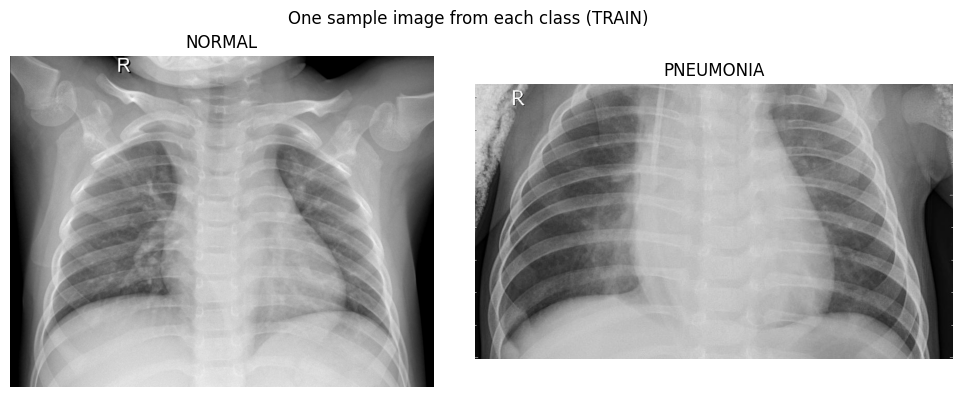

In [5]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/chest_xray"
TRAIN_DIR = os.path.join(ROOT, "train")

classes = ["NORMAL", "PNEUMONIA"]


plt.figure(figsize=(10, 4))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp"))]

    img_path = os.path.join(cls_dir, random.choice(imgs))
    img = Image.open(img_path).convert("RGB")

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"{cls}")
    plt.axis("off")

plt.suptitle("One sample image from each class (TRAIN)")
plt.tight_layout()
plt.show()

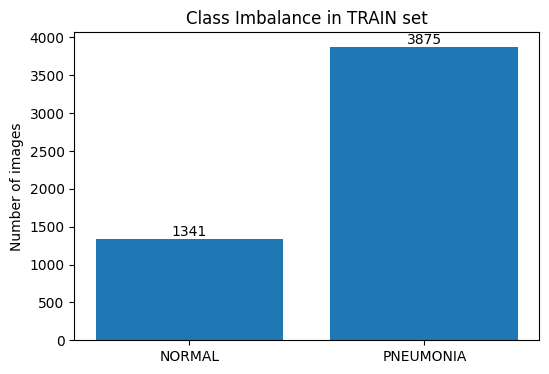

Counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}


In [6]:
counts = []
for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    n = sum(1 for f in os.listdir(cls_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")))
    counts.append(n)

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Class Imbalance in TRAIN set")
plt.ylabel("Number of images")

# show count numbers on bars
for i, c in enumerate(counts):
    plt.text(i, c, str(c), ha="center", va="bottom")

plt.show()

print("Counts:", dict(zip(classes, counts)))

In [7]:
from collections import Counter
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # [-1,1]
])

full_ds = ImageFolder(root=train_root, transform=transform)

# Count images per class
counts = Counter(full_ds.targets)
idx_to_class = {v: k for k, v in full_ds.class_to_idx.items()}

print("Class distribution:")
for idx, c in sorted(counts.items()):
    print(f"  {idx_to_class[idx]}: {c}")

# Pick minority automatically
minority_idx = min(counts, key=counts.get)
minority_class_name = idx_to_class[minority_idx]
print("Detected minority class:", minority_class_name)

# Filter to minority only
minority_samples = [(p, y) for (p, y) in full_ds.samples if y == minority_idx]
full_ds.samples = minority_samples
full_ds.targets = [y for _, y in minority_samples]

print("Minority count:", len(full_ds))

loader = DataLoader(
    full_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)


Class distribution:
  NORMAL: 1341
  PNEUMONIA: 3875
Detected minority class: NORMAL
Minority count: 1341


In [8]:
def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

@torch.no_grad()
def save_sample_grid(images, save_path, nrow=8):
    grid = make_grid(images, nrow=nrow, normalize=True, value_range=(-1, 1))
    save_image(grid, save_path)


In [9]:
class DCGAN_G(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class DCGAN_D(nn.Module):
    def __init__(self, ndf=64, nc=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [10]:
def train_dcgan():
    G = DCGAN_G(nz=nz, nc=nc).to(device)
    D = DCGAN_D(nc=nc).to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    criterion = nn.BCEWithLogitsLoss()
    optG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
    optD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

    fixed_z = torch.randn(64, nz, 1, 1, device=device)

    for epoch in range(1, epochs+1):
        lossG_sum, lossD_sum = 0.0, 0.0

        for real, _ in loader:
            real = real.to(device)
            b = real.size(0)

            # Train D
            z = torch.randn(b, nz, 1, 1, device=device)
            fake = G(z).detach()

            y_real = torch.ones(b, device=device)
            y_fake = torch.zeros(b, device=device)

            lossD = criterion(D(real), y_real) + criterion(D(fake), y_fake)
            optD.zero_grad()
            lossD.backward()
            optD.step()

            # Train G
            z = torch.randn(b, nz, 1, 1, device=device)
            fake = G(z)
            lossG = criterion(D(fake), torch.ones(b, device=device))
            optG.zero_grad()
            lossG.backward()
            optG.step()

            lossD_sum += lossD.item()
            lossG_sum += lossG.item()

        # Save samples
        G.eval()
        with torch.no_grad():
            samples = G(fixed_z)
            save_sample_grid(samples, os.path.join(DCGAN_DIR, f"samples_epoch_{epoch:03d}.png"))

        print(f"[DCGAN] Epoch {epoch}/{epochs} | LossD: {lossD_sum/len(loader):.4f} | LossG: {lossG_sum/len(loader):.4f}")

    return G

dcgan_G = train_dcgan()


[DCGAN] Epoch 1/30 | LossD: 0.1404 | LossG: 9.4488
[DCGAN] Epoch 2/30 | LossD: 0.1123 | LossG: 19.4046
[DCGAN] Epoch 3/30 | LossD: 1.1143 | LossG: 16.2953
[DCGAN] Epoch 4/30 | LossD: 1.3238 | LossG: 11.7576
[DCGAN] Epoch 5/30 | LossD: 1.2584 | LossG: 11.8599
[DCGAN] Epoch 6/30 | LossD: 0.6392 | LossG: 7.9338
[DCGAN] Epoch 7/30 | LossD: 0.3349 | LossG: 6.3581
[DCGAN] Epoch 8/30 | LossD: 0.2107 | LossG: 5.6351
[DCGAN] Epoch 9/30 | LossD: 0.2659 | LossG: 5.9150
[DCGAN] Epoch 10/30 | LossD: 0.2286 | LossG: 5.3591
[DCGAN] Epoch 11/30 | LossD: 0.7211 | LossG: 7.5449
[DCGAN] Epoch 12/30 | LossD: 0.3205 | LossG: 6.0763
[DCGAN] Epoch 13/30 | LossD: 0.3298 | LossG: 6.1553
[DCGAN] Epoch 14/30 | LossD: 0.5000 | LossG: 5.2300
[DCGAN] Epoch 15/30 | LossD: 0.6219 | LossG: 5.7301
[DCGAN] Epoch 16/30 | LossD: 0.6816 | LossG: 5.4402
[DCGAN] Epoch 17/30 | LossD: 0.4143 | LossG: 5.0422
[DCGAN] Epoch 18/30 | LossD: 0.2729 | LossG: 5.2943
[DCGAN] Epoch 19/30 | LossD: 0.6837 | LossG: 6.2826
[DCGAN] Epoch 20/

In [11]:
dcgan_synth_dir = os.path.join(DCGAN_DIR, "synthetic_images")
os.makedirs(dcgan_synth_dir, exist_ok=True)

dcgan_G.eval()
batch = 64
saved = 0

with torch.no_grad():
    while saved < num_synth_to_export:
        b = min(batch, num_synth_to_export - saved)
        z = torch.randn(b, nz, 1, 1, device=device)
        fake = dcgan_G(z)

        for i in range(b):
            save_image(fake[i], os.path.join(dcgan_synth_dir, f"dcgan_{saved+i:05d}.png"),
                       normalize=True, value_range=(-1, 1))
        saved += b

print("Saved DCGAN synthetic images:", saved)


Saved DCGAN synthetic images: 2500


In [12]:
class CGAN_G(nn.Module):
    def __init__(self, nz=100, n_classes=2, emb_dim=50, ngf=64, nc=1):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, emb_dim)
        self.in_dim = nz + emb_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(self.in_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        emb = self.label_emb(labels)
        x = torch.cat([z, emb], dim=1)          # (B, nz+emb)
        x = x.view(x.size(0), x.size(1), 1, 1)  # (B, nz+emb, 1, 1)
        return self.net(x)


class CGAN_D(nn.Module):
    def __init__(self, n_classes=2, emb_dim=50, ndf=64, nc=1, img_size=64):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, img_size * img_size)

        self.net = nn.Sequential(
            nn.Conv2d(nc + 1, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(labels.size(0), 1, image_size, image_size)
        x = torch.cat([img, label_map], dim=1)
        return self.net(x).view(-1)


In [13]:
def train_cgan():
    n_classes = len(full_ds.class_to_idx)  # auto-detect number of classes

    G = CGAN_G(
        nz=nz,
        n_classes=n_classes,
        nc=nc
    ).to(device)

    D = CGAN_D(
        n_classes=n_classes,
        nc=nc,
        img_size=image_size
    ).to(device)

    G.apply(weights_init)
    D.apply(weights_init)

    criterion = nn.BCEWithLogitsLoss()
    optG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
    optD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

    fixed_z = torch.randn(64, nz, device=device)
    fixed_labels = torch.full(
        (64,), minority_idx, dtype=torch.long, device=device
    )

    for epoch in range(1, epochs + 1):
        lossG_sum, lossD_sum = 0.0, 0.0

        for real, _ in loader:
            real = real.to(device)
            b = real.size(0)

            labels = torch.full(
                (b,), minority_idx, dtype=torch.long, device=device
            )


            # Train Discriminator

            z = torch.randn(b, nz, device=device)
            fake = G(z, labels).detach()

            y_real = torch.ones(b, device=device)
            y_fake = torch.zeros(b, device=device)

            lossD = criterion(D(real, labels), y_real) + \
                    criterion(D(fake, labels), y_fake)

            optD.zero_grad()
            lossD.backward()
            optD.step()


            # Train Generator

            z = torch.randn(b, nz, device=device)
            fake = G(z, labels)

            lossG = criterion(D(fake, labels), torch.ones(b, device=device))

            optG.zero_grad()
            lossG.backward()
            optG.step()

            lossD_sum += lossD.item()
            lossG_sum += lossG.item()

        # Save samples
        G.eval()
        with torch.no_grad():
            samples = G(fixed_z, fixed_labels)
            save_sample_grid(
                samples,
                os.path.join(CGAN_DIR, f"samples_epoch_{epoch:03d}.png")
            )

        print(
            f"[CGAN] Epoch {epoch}/{epochs} | "
            f"LossD: {lossD_sum/len(loader):.4f} | "
            f"LossG: {lossG_sum/len(loader):.4f}"
        )

    return G


cgan_G = train_cgan()


[CGAN] Epoch 1/30 | LossD: 3.8677 | LossG: 3.2655
[CGAN] Epoch 2/30 | LossD: 2.7098 | LossG: 3.0562
[CGAN] Epoch 3/30 | LossD: 2.0618 | LossG: 2.2883
[CGAN] Epoch 4/30 | LossD: 1.8808 | LossG: 1.9596
[CGAN] Epoch 5/30 | LossD: 1.6879 | LossG: 2.1602
[CGAN] Epoch 6/30 | LossD: 1.5677 | LossG: 2.3061
[CGAN] Epoch 7/30 | LossD: 1.3871 | LossG: 2.7718
[CGAN] Epoch 8/30 | LossD: 1.6002 | LossG: 2.8435
[CGAN] Epoch 9/30 | LossD: 1.1351 | LossG: 3.2011
[CGAN] Epoch 10/30 | LossD: 1.5934 | LossG: 3.0157
[CGAN] Epoch 11/30 | LossD: 1.0600 | LossG: 3.5786
[CGAN] Epoch 12/30 | LossD: 0.8037 | LossG: 3.9705
[CGAN] Epoch 13/30 | LossD: 1.2390 | LossG: 4.2687
[CGAN] Epoch 14/30 | LossD: 0.7607 | LossG: 4.0308
[CGAN] Epoch 15/30 | LossD: 0.5766 | LossG: 4.3424
[CGAN] Epoch 16/30 | LossD: 0.4925 | LossG: 4.0862
[CGAN] Epoch 17/30 | LossD: 0.4427 | LossG: 4.5792
[CGAN] Epoch 18/30 | LossD: 0.4297 | LossG: 4.1866
[CGAN] Epoch 19/30 | LossD: 1.1231 | LossG: 3.3102
[CGAN] Epoch 20/30 | LossD: 1.6975 | Los

In [14]:
cgan_synth_dir = os.path.join(CGAN_DIR, "synthetic_images")
os.makedirs(cgan_synth_dir, exist_ok=True)

cgan_G.eval()
batch = 64
saved = 0

with torch.no_grad():
    while saved < num_synth_to_export:
        b = min(batch, num_synth_to_export - saved)
        z = torch.randn(b, nz, device=device)
        labels = torch.ones(b, dtype=torch.long, device=device)  # all normal
        fake = cgan_G(z, labels)

        for i in range(b):
            save_image(fake[i], os.path.join(cgan_synth_dir, f"cgan_{saved+i:05d}.png"),
                       normalize=True, value_range=(-1, 1))
        saved += b

print("Saved CGAN synthetic images:", saved)


Saved CGAN synthetic images: 2500


In [15]:
!zip -r gan_outputs.zip /content/gan_outputs


Streaming output truncated to the last 5000 lines.
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_01441.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_01536.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_02484.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_01509.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_02372.png (deflated 1%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_02440.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_00569.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_00937.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_00961.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_01781.png (deflated 2%)
  adding: content/gan_outputs/dcgan/synthetic_images/dcgan_00585.png (deflated 1%)
  adding: content/gan_outputs/dcgan/

In [16]:
import os, shutil, random
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [17]:
train_root = "/content/drive/MyDrive/chest_xray/train"
test_root  = "/content/drive/MyDrive/chest_xray/test"

dcgan_synth_dir = "/content/gan_outputs/dcgan/synthetic_images"
cgan_synth_dir  = "/content/gan_outputs/cgan/synthetic_images"

BALANCED_ROOT = "/content/balanced_sets"
os.makedirs(BALANCED_ROOT, exist_ok=True)


In [18]:
def count_images(root):
    counts = {}
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    return counts

train_counts = count_images(train_root)
print("Train distribution:", train_counts)

minority_class = min(train_counts, key=train_counts.get)
majority_class = max(train_counts, key=train_counts.get)

need = train_counts[majority_class] - train_counts[minority_class]
print("Minority:", minority_class, "| Majority:", majority_class)
print("Images needed to balance:", need)


Train distribution: {'PNEUMONIA': 3875, 'NORMAL': 1341}
Minority: NORMAL | Majority: PNEUMONIA
Images needed to balance: 2534


In [19]:
def build_balanced_train(original_train_root, synth_dir, out_root, minority_class, need):
    # recreate output
    if os.path.exists(out_root):
        shutil.rmtree(out_root)
    shutil.copytree(original_train_root, out_root)

    # add synthetic images into minority folder
    target_dir = os.path.join(out_root, minority_class)
    os.makedirs(target_dir, exist_ok=True)

    synth_files = [f for f in os.listdir(synth_dir) if f.lower().endswith((".png",".jpg",".jpeg"))]
    if len(synth_files) < need:
        print(f"Not enough synth images in {synth_dir}. Have {len(synth_files)}, need {need}. Will use all.")
        chosen = synth_files
    else:
        chosen = random.sample(synth_files, need)

    for i, f in enumerate(chosen):
        src = os.path.join(synth_dir, f)
        dst = os.path.join(target_dir, f"synth_{i:06d}.png")
        shutil.copy2(src, dst)

    return out_root

dcgan_bal_train = os.path.join(BALANCED_ROOT, "train_balanced_dcgan")
cgan_bal_train  = os.path.join(BALANCED_ROOT, "train_balanced_cgan")

build_balanced_train(train_root, dcgan_synth_dir, dcgan_bal_train, minority_class, need)
build_balanced_train(train_root, cgan_synth_dir,  cgan_bal_train,  minority_class, need)

print("DCGAN balanced counts:", count_images(dcgan_bal_train))
print("CGAN  balanced counts:", count_images(cgan_bal_train))


Not enough synth images in /content/gan_outputs/dcgan/synthetic_images. Have 2500, need 2534. Will use all.
Not enough synth images in /content/gan_outputs/cgan/synthetic_images. Have 2500, need 2534. Will use all.
DCGAN balanced counts: {'PNEUMONIA': 3875, 'NORMAL': 3841}
CGAN  balanced counts: {'PNEUMONIA': 3875, 'NORMAL': 3841}


In [20]:
image_size = 64

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def make_loaders(train_dir, test_dir, batch_size=64, num_workers=2):
    train_ds = ImageFolder(train_dir, transform=train_tf)
    test_ds  = ImageFolder(test_dir,  transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, train_ds.class_to_idx

train_loader_imb, test_loader, class_to_idx = make_loaders(train_root, test_root)
train_loader_dcgan, _, _ = make_loaders(dcgan_bal_train, test_root)
train_loader_cgan,  _, _ = make_loaders(cgan_bal_train,  test_root)

print("Class mapping:", class_to_idx)


Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [21]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32x32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def train_one(model, train_loader, test_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = crit(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {ep}/{epochs} | train loss: {total_loss/len(train_loader):.4f}")

    # evaluate
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


In [23]:
idx_to_class = {v:k for k,v in class_to_idx.items()}

def show_results(name, acc, y_true, y_pred):
    print(f"\n================ {name} ================")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, target_names=[idx_to_class[0], idx_to_class[1]]))

# 1) Original imbalanced
m1 = SimpleCNN(num_classes=2)
acc1, yt1, yp1 = train_one(m1, train_loader_imb, test_loader, epochs=5, lr=1e-3)
show_results("Imbalanced (Original)", acc1, yt1, yp1)

# 2) Balanced using Vanilla GAN (DCGAN)
m2 = SimpleCNN(num_classes=2)
acc2, yt2, yp2 = train_one(m2, train_loader_dcgan, test_loader, epochs=5, lr=1e-3)
show_results("Balanced with Vanilla GAN (DCGAN)", acc2, yt2, yp2)

# 3) Balanced using GAN variant (CGAN)
m3 = SimpleCNN(num_classes=2)
acc3, yt3, yp3 = train_one(m3, train_loader_cgan, test_loader, epochs=5, lr=1e-3)
show_results("Balanced with GAN Variant (CGAN)", acc3, yt3, yp3)


Epoch 1/5 | train loss: 0.2831
Epoch 2/5 | train loss: 0.1429
Epoch 3/5 | train loss: 0.1054
Epoch 4/5 | train loss: 0.0903
Epoch 5/5 | train loss: 0.0845

================ Imbalanced (Original) ================
Accuracy: 0.7483974358974359
Confusion Matrix:
 [[ 83 151]
 [  6 384]]

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.93      0.35      0.51       234
   PNEUMONIA       0.72      0.98      0.83       390

    accuracy                           0.75       624
   macro avg       0.83      0.67      0.67       624
weighted avg       0.80      0.75      0.71       624

Epoch 1/5 | train loss: 0.1848
Epoch 2/5 | train loss: 0.0903
Epoch 3/5 | train loss: 0.0657
Epoch 4/5 | train loss: 0.0566
Epoch 5/5 | train loss: 0.0509

================ Balanced with Vanilla GAN (DCGAN) ================
Accuracy: 0.7548076923076923
Confusion Matrix:
 [[ 84 150]
 [  3 387]]

Classification Report:
               precision    recall  f1-score  

In [24]:
!pip -q install scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)


In [25]:
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

def get_preds_probs(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    y_prob_pos = []  # probability of class 1

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)                       # (B,2)
            probs = F.softmax(logits, dim=1).cpu().numpy()

            pred = np.argmax(probs, axis=1)
            prob_pos = probs[:, 1]

            y_true.extend(y.numpy())
            y_pred.extend(pred)
            y_prob_pos.extend(prob_pos)

    return np.array(y_true), np.array(y_pred), np.array(y_prob_pos)


In [26]:
def compute_metrics(y_true, y_pred, y_prob_pos):
    metrics = {}
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, average="binary")
    metrics["recall"] = recall_score(y_true, y_pred, average="binary")
    metrics["f1"] = f1_score(y_true, y_pred, average="binary")

    try:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob_pos)
    except ValueError:
        metrics["auc_roc"] = np.nan

    metrics["cm"] = confusion_matrix(y_true, y_pred)
    return metrics


In [27]:
m1 = m1.to(device)
m2 = m2.to(device)
m3 = m3.to(device)

y1_true, y1_pred, y1_prob = get_preds_probs(m1, test_loader)
y2_true, y2_pred, y2_prob = get_preds_probs(m2, test_loader)
y3_true, y3_pred, y3_prob = get_preds_probs(m3, test_loader)

met1 = compute_metrics(y1_true, y1_pred, y1_prob)
met2 = compute_metrics(y2_true, y2_pred, y2_prob)
met3 = compute_metrics(y3_true, y3_pred, y3_prob)

met1, met2, met3


({'accuracy': 0.7483974358974359,
  'precision': 0.7177570093457943,
  'recall': 0.9846153846153847,
  'f1': 0.8302702702702702,
  'auc_roc': np.float64(0.873948060486522),
  'cm': array([[ 83, 151],
         [  6, 384]])},
 {'accuracy': 0.7548076923076923,
  'precision': 0.7206703910614525,
  'recall': 0.9923076923076923,
  'f1': 0.8349514563106796,
  'auc_roc': np.float64(0.8676528599605523),
  'cm': array([[ 84, 150],
         [  3, 387]])},
 {'accuracy': 0.8012820512820513,
  'precision': 0.766,
  'recall': 0.982051282051282,
  'f1': 0.8606741573033708,
  'auc_roc': np.float64(0.8751698444006136),
  'cm': array([[117, 117],
         [  7, 383]])})

In [28]:
import pandas as pd

rows = [
    ["Imbalanced (Original)", met1["accuracy"], met1["precision"], met1["recall"], met1["f1"], met1["auc_roc"]],
    ["Balanced (DCGAN)",      met2["accuracy"], met2["precision"], met2["recall"], met2["f1"], met2["auc_roc"]],
    ["Balanced (CGAN)",       met3["accuracy"], met3["precision"], met3["recall"], met3["f1"], met3["auc_roc"]],
]

df = pd.DataFrame(rows, columns=["Scenario","Accuracy","Precision","Recall","F1","AUC-ROC"])
df


,Scenario,Accuracy,Precision,Recall,F1,AUC-ROC
0,Imbalanced (Original),0.748397,0.717757,0.984615,0.830270,0.873948
1,Balanced (DCGAN),0.754808,0.720670,0.992308,0.834951,0.867653
2,Balanced (CGAN),0.801282,0.766000,0.982051,0.860674,0.875170


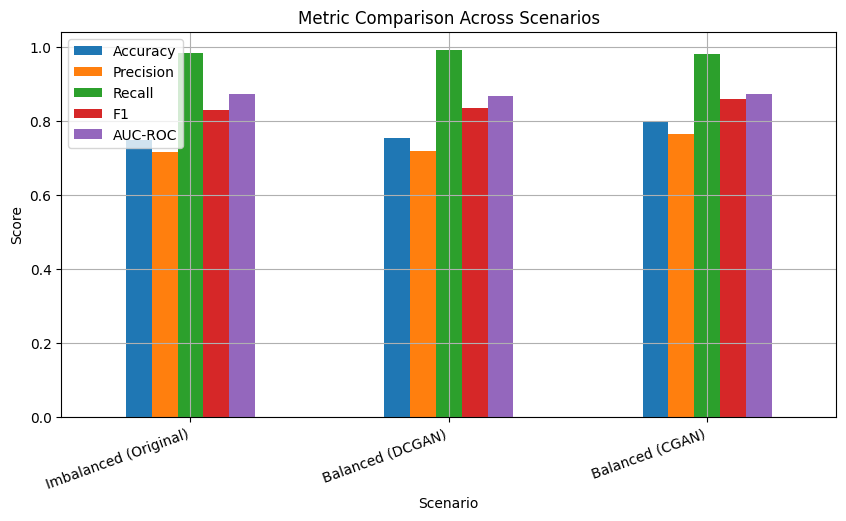

In [29]:
df_plot = df.set_index("Scenario")[["Accuracy","Precision","Recall","F1","AUC-ROC"]]
ax = df_plot.plot(kind="bar", figsize=(10,5))
plt.xticks(rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Metric Comparison Across Scenarios")
plt.grid(True)
plt.show()


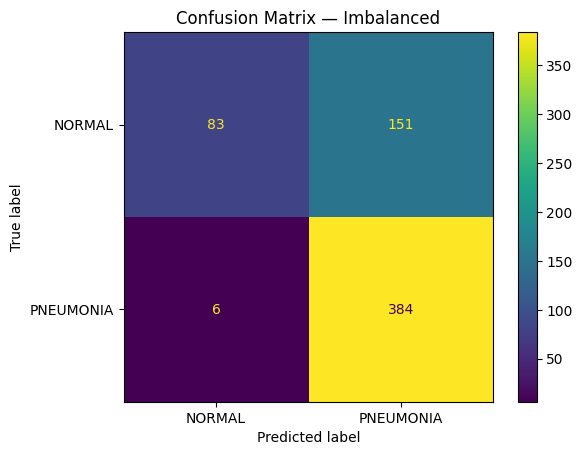

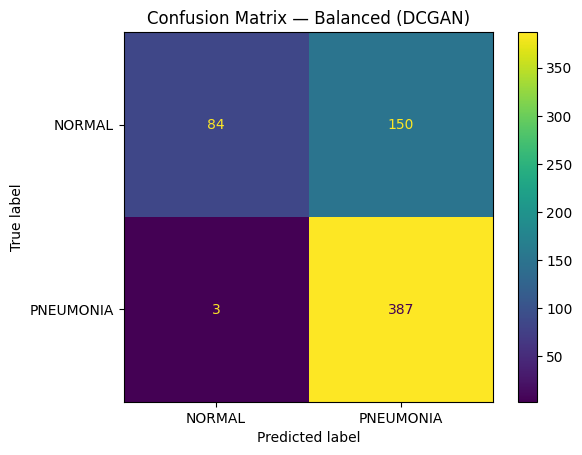

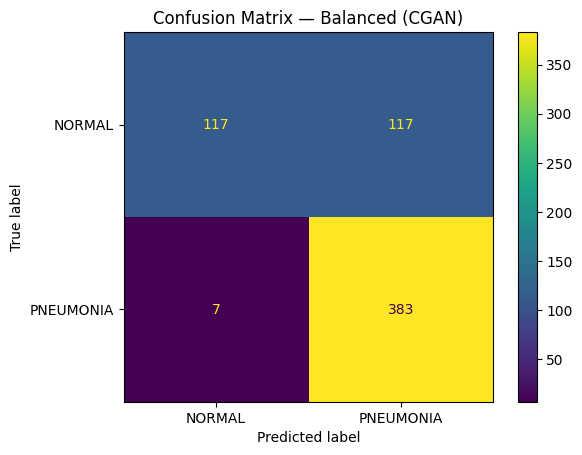

In [30]:
def plot_cm(cm, title, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title(title)
    plt.grid(False)
    plt.show()

idx_to_class = {v:k for k,v in class_to_idx.items()}
labels = [idx_to_class[0], idx_to_class[1]]

plot_cm(met1["cm"], "Confusion Matrix — Imbalanced", labels)
plot_cm(met2["cm"], "Confusion Matrix — Balanced (DCGAN)", labels)
plot_cm(met3["cm"], "Confusion Matrix — Balanced (CGAN)", labels)


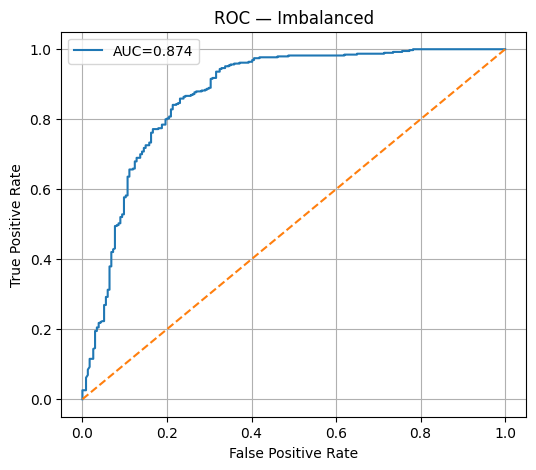

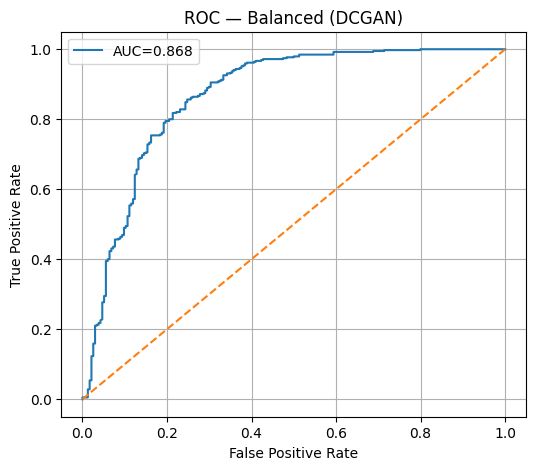

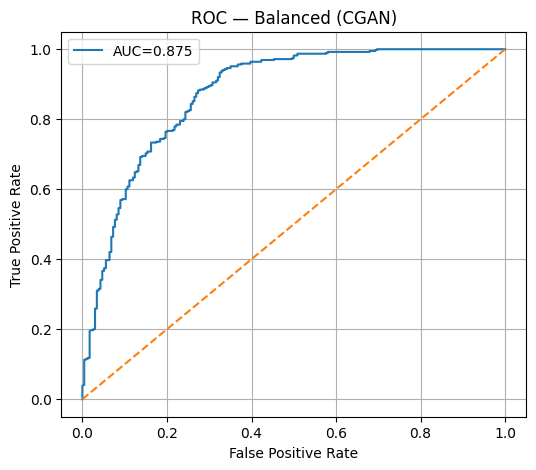

In [31]:
def plot_roc(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc(y1_true, y1_prob, "ROC — Imbalanced")
plot_roc(y2_true, y2_prob, "ROC — Balanced (DCGAN)")
plot_roc(y3_true, y3_prob, "ROC — Balanced (CGAN)")


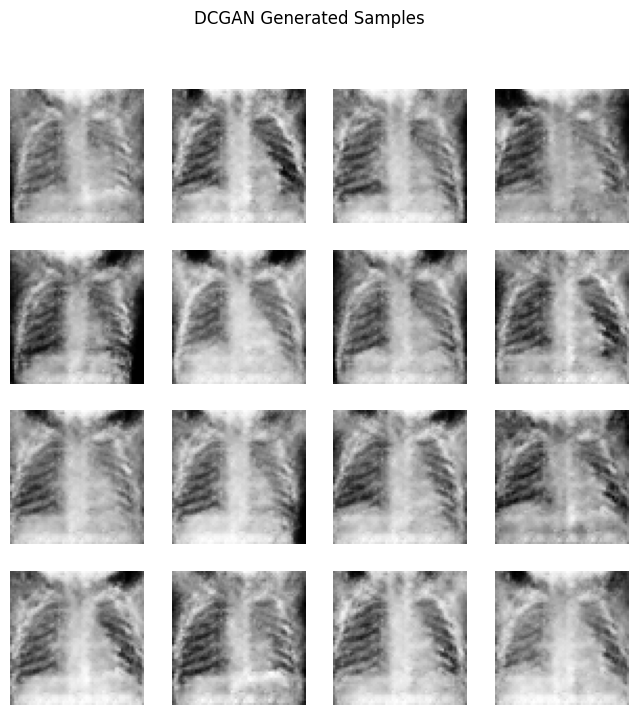

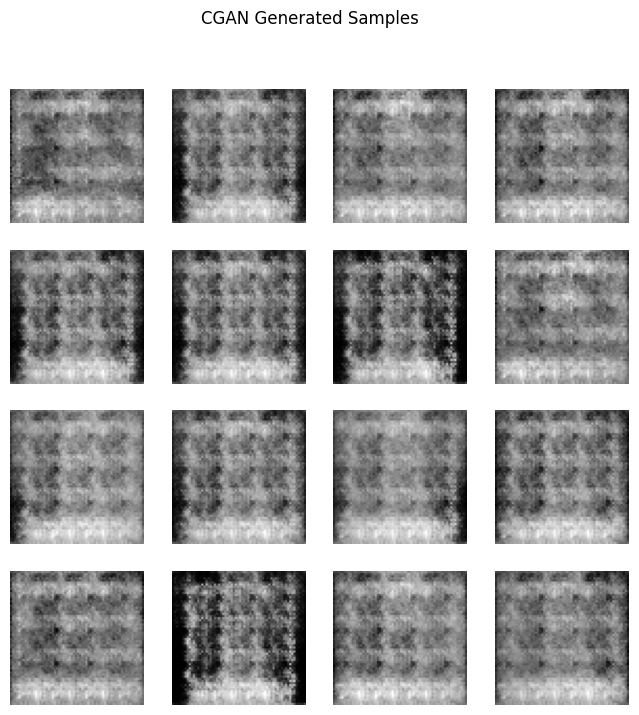

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

def show_generated_samples(folder, n=16, title=""):
    files = [f for f in os.listdir(folder) if f.lower().endswith((".png",".jpg",".jpeg"))]
    files = random.sample(files, min(n, len(files)))

    cols = int(np.sqrt(n))
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(8,8))
    for i, f in enumerate(files):
        img = Image.open(os.path.join(folder, f)).convert("L")
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_generated_samples(dcgan_synth_dir, n=16, title="DCGAN Generated Samples")
show_generated_samples(cgan_synth_dir,  n=16, title="CGAN Generated Samples")
